In [1]:
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.model_selection import train_test_split
from src.train_utils import compare_models, evaluate_and_save

In [2]:
df = pd.read_csv("../data/parkinsons.csv")
df = df.drop(columns=["name"])
print(df.shape)
print(df["status"].value_counts())
df.head()

(195, 23)
status
1    147
0     48
Name: count, dtype: int64


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [3]:
X = df.drop("status", axis=1)
y = df["status"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
results = compare_models(X_train, y_train)
results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.898,0.913,0.957,0.933,0.954
1,Gradient Boosting,0.872,0.899,0.941,0.917,0.951
2,Logistic Regression,0.821,0.853,0.924,0.887,0.898
3,SVM,0.853,0.843,0.991,0.911,0.891


Best model: Random Forest
              precision    recall  f1-score   support

     Healthy       0.89      0.80      0.84        10
 Parkinson's       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



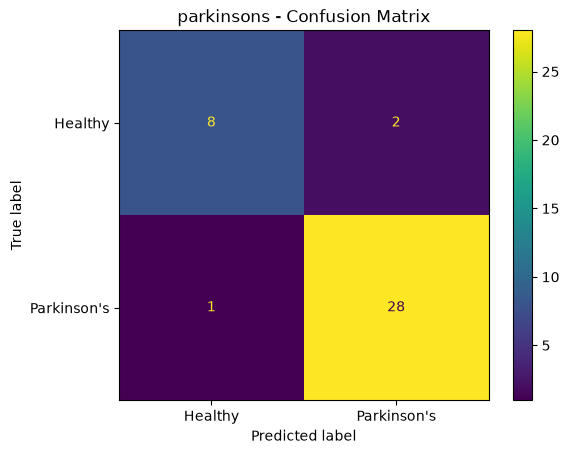

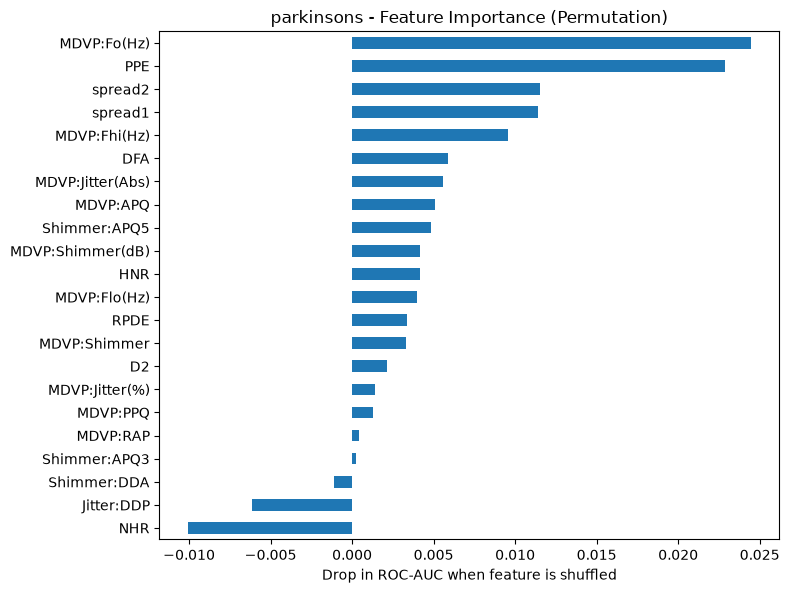

Saved models/parkinsons_model.joblib | Test ROC-AUC: 0.962


In [4]:
_ = evaluate_and_save(results, X, X_train, X_test, y_train, y_test,
                      tag="parkinsons", labels=["Healthy", "Parkinson's"])